In [1]:
#IMPORTANT NOTE : AFTER TRAINING(running) THE MODEL ; USE THE COMMAND 'streamlit run app.py' in the terminal TO RUN THE APP 

# the price of a laptop based on its specifications. The model is trained on a dataset of laptop prices and their corresponding features. 
# The features include brand, processor type, RAM size, storage capacity, screen size, and other relevant specifications.
#  The model uses a regression algorithm to learn the relationship between the features and the laptop prices and also uses hyperparameters to optimize its performance via random forest. 
# Once trained, the model can be used to predict the price of a laptop based on its specifications. 
# Additionally,I have also created an advisor system that provides recommendations to users based on their preferences and budget. Theadvisor takes into account the user's requirements and suggests laptops that best fit their needs while considering the predicted prices.
#  The advisor can help users make informed decisions when purchasing a laptop by providing insights into the expected price range for different configurations and guiding them towards options that align with their budget and preferences. 
# I have used streamlit to create a user-friendly interface for the advisor system, allowing users to input their preferences and receive personalized laptop recommendations. The interface is designed to be intuitive and easy to navigate, making it accessible to a wide range of users.
# As of now the project is limied to the laptops that came long befor due to the inavailability of datasets for the latest models, but I have plans to update the dataset and model in the future to include more recent laptop models and their specifications.
# -I have an vision of expanding this suggestor tool to work with all the gadgets but due to time constraints and project scope, I have focused on laptops for this project. However, the underlying principles and techniques can be applied to other gadgets in the future, allowing for a more comprehensive and versatile recommendation system.






import pandas as pd
import numpy as np
import pickle
df = pd.read_csv('laptop_data_cleaned.csv')
df.head()
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1273 non-null   object 
 1   TypeName     1273 non-null   object 
 2   Ram          1273 non-null   int64  
 3   Weight       1273 non-null   float64
 4   Price        1273 non-null   float64
 5   TouchScreen  1273 non-null   int64  
 6   Ips          1273 non-null   int64  
 7   Ppi          1273 non-null   float64
 8   Cpu_brand    1273 non-null   object 
 9   HDD          1273 non-null   int64  
 10  SSD          1273 non-null   int64  
 11  Gpu_brand    1273 non-null   object 
 12  Os           1273 non-null   object 
dtypes: float64(3), int64(5), object(5)
memory usage: 129.4+ KB


,Ram,Weight,Price,TouchScreen,Ips,Ppi,HDD,SSD
count,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000
mean,8.447761,2.041100,10.828218,0.146897,0.279654,146.950812,413.715632,186.252946
std,5.098771,0.669241,0.619565,0.354142,0.449006,42.926775,518.054486,186.531571
min,2.000000,0.690000,9.134616,0.000000,0.000000,90.583402,0.000000,0.000000
25%,4.000000,1.500000,10.387379,0.000000,0.000000,127.335675,0.000000,0.000000
50%,8.000000,2.040000,10.872255,0.000000,0.000000,141.211998,0.000000,256.000000
75%,8.000000,2.310000,11.287447,0.000000,1.000000,157.350512,1000.000000,256.000000
max,64.000000,4.700000,12.691441,1.000000,1.000000,352.465147,2000.000000,1024.000000


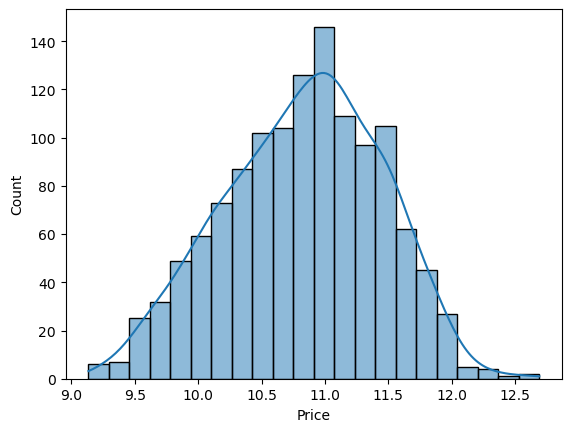

In [2]:
#EDA PART in our model
df.isnull().sum()
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Price'], kde=True)
plt.show()


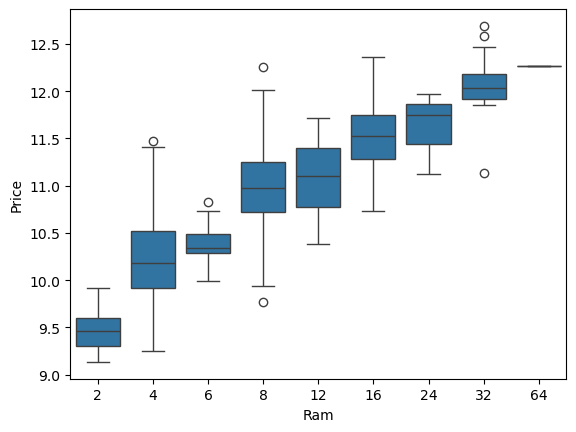

In [3]:
sns.boxplot(x=df['Ram'], y=df['Price'])
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'Apple'),
  Text(1, 0, 'HP'),
  Text(2, 0, 'Acer'),
  Text(3, 0, 'Asus'),
  Text(4, 0, 'Dell'),
  Text(5, 0, 'Lenovo'),
  Text(6, 0, 'Chuwi'),
  Text(7, 0, 'MSI'),
  Text(8, 0, 'Microsoft'),
  Text(9, 0, 'Toshiba'),
  Text(10, 0, 'Huawei'),
  Text(11, 0, 'Xiaomi'),
  Text(12, 0, 'Vero'),
  Text(13, 0, 'Razer'),
  Text(14, 0, 'Mediacom'),
  Text(15, 0, 'Samsung'),
  Text(16, 0, 'Google'),
  Text(17, 0, 'Fujitsu'),
  Text(18, 0, 'LG')])

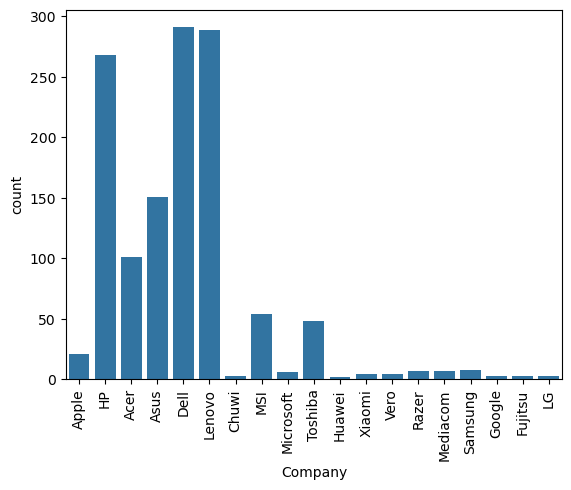

In [4]:
sns.countplot(x=df['Company'])
plt.xticks(rotation=90)

In [5]:
df = pd.get_dummies(df, columns=[
    "Company",
    "TypeName",
    "Cpu_brand",
    "Gpu_brand",
    "Os"
], drop_first=True)

In [6]:
from sklearn.model_selection import train_test_split
X = df.drop('Price' , axis=1)
Y = df["Price"]
X_train , X_test, Y_train , Y_test = train_test_split(X,Y,test_size=0.2 , random_state=42)

In [7]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])

0

In [8]:
from xgboost import XGBRegressor

model = XGBRegressor()

model.fit(X_train, Y_train)

pred = model.predict(X_test)

In [9]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(Y_test, pred))
print("Root Mean Squared Error: ", rmse)


Root Mean Squared Error:  0.21252396562585843


In [10]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators":[100,200,300],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.1,0.2]
}

grid = GridSearchCV(
    XGBRegressor(),
    params,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train, Y_train)

print(grid.best_params_)

{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}


In [11]:
best_model = grid.best_estimator_
pred2 = best_model.predict(X_test)
rmse2 = np.sqrt(mean_squared_error(Y_test, pred2))
print("Root Mean Squared Error after Hyperparameter Tuning: ", rmse2)
pickle.dump(best_model, open("laptop_model.pkl", "wb"))
pickle.dump(X_train.columns, open("columns.pkl", "wb"))

Root Mean Squared Error after Hyperparameter Tuning:  0.22281078429423082


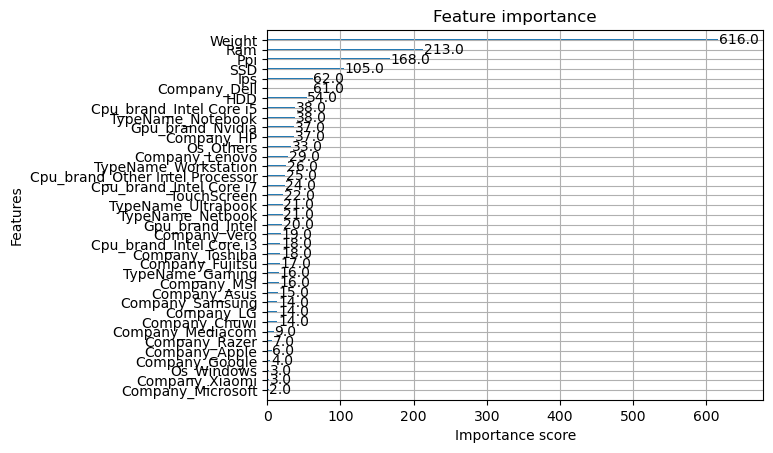

In [12]:
#feature importance - demonstration

from xgboost import plot_importance
plot_importance(best_model)
plt.show()

In [13]:
# #Laptop advisor model that helps people to pick a laptop that has the best feature-to-price
# def recommend_laptop(ram, budget):
#     results = df[
#         (df['Ram'] >= ram) &
#         (df['Price'] <= budget)
#     ]
#     return results.sort_values(by="Price").head(5)

In [14]:
df["value_score"] = (df["Ram"] + df["SSD"]/128) / df["Price"]
df.sort_values(by="value_score", ascending=False).head(10)

,Ram,Weight,Price,TouchScreen,Ips,Ppi,HDD,SSD,Company_Apple,Company_Asus,...,TypeName_Workstation,Cpu_brand_Intel Core i3,Cpu_brand_Intel Core i5,Cpu_brand_Intel Core i7,Cpu_brand_Other Intel Processor,Gpu_brand_Intel,Gpu_brand_Nvidia,Os_Others,Os_Windows,value_score
1066,64,3.58,12.263341,0,1,127.335675,0,1000,False,True,...,False,False,False,True,False,False,True,False,True,5.855867
329,32,2.06,11.853716,1,0,282.423996,0,1000,False,False,...,False,False,False,True,False,False,True,False,True,3.358651
780,32,4.42,12.161134,0,1,127.335675,1000,1000,False,False,...,False,False,False,True,False,False,True,False,True,3.273749
723,32,4.36,12.180616,0,0,254.671349,1000,1000,False,False,...,False,False,False,True,False,False,True,False,True,3.268513
901,32,3.58,11.129395,0,1,127.335675,0,512,False,True,...,False,False,False,True,False,False,True,False,True,3.234677
610,32,2.50,12.472347,0,1,282.423996,0,1000,False,False,...,False,False,False,False,True,False,True,False,True,3.192062
196,32,3.49,12.691441,1,0,254.671349,0,1000,False,False,...,False,False,False,True,False,False,True,False,True,3.136957
650,32,3.80,11.912579,0,1,127.335675,0,512,False,True,...,False,False,False,True,False,False,True,False,True,3.022016
491,32,1.05,11.912579,1,0,165.632118,0,512,False,False,...,False,False,False,True,False,True,False,False,True,3.022016
177,32,4.40,11.912579,0,0,119.723216,1000,512,False,False,...,False,False,False,True,False,False,True,False,True,3.022016
